In [1]:
import pandas as pd
import numpy as np

# ---------- utils ----------
def clip_and_log_transform(y: np.ndarray):
    y = np.clip(y, a_min=0, a_max=None)
    return np.log10(y + 1)

def bootstrap_sampling(size: int, n_samples: int) -> np.ndarray:
    rng = np.random.default_rng(0)
    return rng.choice(size, size=(n_samples, size), replace=True)

def metrics_per_ep(pred: np.ndarray, true: np.ndarray):
    from scipy.stats import spearmanr, kendalltau
    from sklearn.metrics import mean_absolute_error, r2_score

    mae = mean_absolute_error(true, pred)
    rae = mae / np.mean(np.abs(true - np.mean(true)))

    if np.nanstd(true) == 0:
        r2 = np.nan
    else:
        r2 = r2_score(true, pred)

    spr = spearmanr(true, pred).statistic
    ktau = kendalltau(true, pred).statistic

    return mae, rae, r2, spr, ktau

def bootstrap_metrics(pred: np.ndarray, true: np.ndarray, endpoint: str, n_bootstrap_samples=1000):
    cols = ["Sample", "Endpoint", "Metric", "Value"]
    bootstrap_results = pd.DataFrame(columns=cols)

    for i, indx in enumerate(bootstrap_sampling(true.shape[0], n_bootstrap_samples)):
        mae, rae, r2, spr, ktau = metrics_per_ep(pred[indx], true[indx])
        scores = pd.DataFrame(
            [
                [i, endpoint, "MAE", mae],
                [i, endpoint, "RAE", rae],
                [i, endpoint, "R2", r2],
                [i, endpoint, "Spearman R", spr],
                [i, endpoint, "Kendall's Tau", ktau],
            ],
            columns=cols,
        )
        bootstrap_results = pd.concat([bootstrap_results, scores], ignore_index=True)

    return bootstrap_results

# ---------- metric calculation ----------
ENDPOINTS = ["HLM"]

def _check_required_columns(df: pd.DataFrame, name: str, cols: list[str]):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")

def calculate_metrics_notebook(results_dataframe: pd.DataFrame, test_dataframe: pd.DataFrame):
    _check_required_columns(results_dataframe, "Results file", ["Molecule Name"] + ENDPOINTS)
    _check_required_columns(test_dataframe, "Test file", ["Molecule Name"] + ENDPOINTS)

    if not test_dataframe["Molecule Name"].isin(results_dataframe["Molecule Name"]).all():
        raise ValueError("The predictions file is missing some molecules present in the test set.")

    if results_dataframe["Molecule Name"].duplicated().any():
        raise ValueError("The predictions file contains duplicated molecules.")

    merged_df = results_dataframe.merge(
        test_dataframe,
        on="Molecule Name",
        suffixes=("_pred", "_true"),
        how="inner"
    ).sort_values("Molecule Name")

    final_cols = ["MAE", "RAE", "R2", "Spearman R", "Kendall's Tau"]
    all_endpoint_results = []

    for ept in ENDPOINTS:
        pred_col = f"{ept}_pred"
        true_col = f"{ept}_true"

        merged_df[pred_col] = pd.to_numeric(merged_df[pred_col], errors="coerce")
        merged_df[true_col] = pd.to_numeric(merged_df[true_col], errors="coerce")

        if merged_df[pred_col].isnull().all():
            raise ValueError(f"All predictions are missing for endpoint {ept}.")

        subset = merged_df[[pred_col, true_col]].dropna()
        if subset.empty:
            raise ValueError(f"No valid data available for endpoint {ept} after removing NaNs.")

        y_pred = subset[pred_col].to_numpy()
        y_true = subset[true_col].to_numpy()

        # HLM is evaluated on log10(value + 1), matching your app logic
        y_true_log = clip_and_log_transform(y_true)
        y_pred_log = clip_and_log_transform(y_pred)

        bootstrap_df = bootstrap_metrics(y_pred_log, y_true_log, ept, n_bootstrap_samples=1000)

        df_endpoint = bootstrap_df.pivot_table(
            index=["Endpoint"],
            columns="Metric",
            values="Value",
            aggfunc=["mean", "std"]
        ).reset_index()

        df_endpoint.columns = [f"{i}_{j}" if i != "" else j for i, j in df_endpoint.columns]
        df_endpoint.rename(columns={"Endpoint_": "Endpoint"}, inplace=True)
        all_endpoint_results.append(df_endpoint)

    df_results = pd.concat(all_endpoint_results, ignore_index=True)

    mean_cols = [f"mean_{m}" for m in final_cols]
    std_cols = [f"std_{m}" for m in final_cols]

    macro_means = df_results[mean_cols].mean()
    macro_stds = df_results[std_cols].mean()

    avg_row = {"Endpoint": "Macro Average"}
    avg_row.update(macro_means.to_dict())
    avg_row.update(macro_stds.to_dict())

    df_with_average = pd.concat([df_results, pd.DataFrame([avg_row])], ignore_index=True)
    df_with_average = df_with_average[["Endpoint"] + mean_cols + std_cols]

    return df_with_average

In [2]:
def compare_prediction_dfs(
    prediction_dfs,
    test_df,
    names=None,
    true_col="hlm_value_true",
    endpoint_name="HLM",
    use_macro_average=False,
):
    if names is None:
        names = [f"Model {i+1}" for i in range(len(prediction_dfs))]

    if len(names) != len(prediction_dfs):
        raise ValueError("Length of names must match length of prediction_dfs.")

    rows = []

    for name, pred_df in zip(names, prediction_dfs):
        pred_df = pred_df.copy()

        # Prefer raw predictions if already present, otherwise convert from log1p
        if "y_pred_normal" in pred_df.columns:
            pred_values_col = "y_pred_normal"
        elif "y_pred_log1p" in pred_df.columns:
            pred_df["y_pred_normal"] = np.expm1(pd.to_numeric(pred_df["y_pred_log1p"], errors="coerce"))
            pred_values_col = "y_pred_normal"
        else:
            raise ValueError(
                f"{name} must contain either 'y_pred_normal' or 'y_pred_log1p'."
            )

        results_df = pred_df[["Molecule Name", pred_values_col]].rename(
            columns={pred_values_col: endpoint_name}
        )
        truth_df = test_df[["Molecule Name", true_col]].rename(
            columns={true_col: endpoint_name}
        )

        metrics_df = calculate_metrics_notebook(results_df, truth_df)

        if use_macro_average:
            row = metrics_df.loc[metrics_df["Endpoint"] == "Macro Average"].copy()
        else:
            row = metrics_df.loc[metrics_df["Endpoint"] == endpoint_name].copy()

        if row.empty:
            raise ValueError(f"No metrics row found for {name}.")

        row.insert(0, "Name", name)
        rows.append(row)

    comparison_df = pd.concat(rows, ignore_index=True)
    comparison_df = comparison_df.sort_values("mean_MAE", ascending=True).reset_index(drop=True)
    comparison_df.insert(0, "Rank", range(1, len(comparison_df) + 1))

    first_cols = ["Rank", "Name", "Endpoint"]
    other_cols = [c for c in comparison_df.columns if c not in first_cols]
    comparison_df = comparison_df[first_cols + other_cols]

    return comparison_df

In [3]:
df1 = pd.read_csv("Predictions/predictions_all_novartis_scaffold_chemeleon.csv")
df2 = pd.read_csv("Predictions/predictions_all_scaffold_chemeleon_best.csv")
df3 = pd.read_csv("Predictions/predictions_no_scale_scaffold_chemeleon.csv")
df4 = pd.read_csv("Predictions/predictions_expansion_scaffold_chemeleon.csv")
df5 = pd.read_csv("Predictions/predictions_expansion_scaffold_chemprop_chemeleon.csv")

In [4]:
# load the AD file
test_ad_expansion = pd.read_csv("AD/test_ad_chemeleon_expansion.csv")
test_ad_no_scale = pd.read_csv("AD/test_ad_chemeleon_no_scale.csv")
test_ad_all = pd.read_csv("AD/test_ad_chemeleon_all.csv")

# bring the column into your predictions df by matching on Molecule Name
df2 = df2.merge(
    test_ad_all[["Molecule Name", "outside_ad_train_all_user_cutoff"]],
    on="Molecule Name",
    how="left"
)

df3 = df3.merge(
    test_ad_no_scale[["Molecule Name", "outside_ad_train_all_user_cutoff"]],
    on="Molecule Name",
    how="left"
)

df4 = df4.merge(
    test_ad_expansion[["Molecule Name", "outside_ad_train_all_user_cutoff"]],
    on="Molecule Name",
    how="left"
)

df5 = df5.merge(
    test_ad_expansion[["Molecule Name", "outside_ad_train_all_user_cutoff"]],
    on="Molecule Name",
    how="left"
)

In [5]:
comparison_df = compare_prediction_dfs(
    prediction_dfs=[df1, df2, df3, df4, df5],
    test_df=df1,  # your dataframe with hlm_value_true
    names=["All_Novartis_Autogluon_Chemeleon", "All_Autogluon_Chemeleon", "No_scale_Autogluon_Chemeleon", "Expansion_Autogluon_Chemeleon", "Expansion_Chemprop_Chemeleon"],
    true_col="hlm_value_true",
)

comparison_df

C:\Users\talag\AppData\Local\Temp\ipykernel_14364\749651188.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bootstrap_results = pd.concat([bootstrap_results, scores], ignore_index=True)
C:\Users\talag\AppData\Local\Temp\ipykernel_14364\749651188.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bootstrap_results = pd.concat([bootstrap_results, scores], ignore_index=True)
C:\Users\talag\AppData\Local\Temp\ipykernel_14364\749651188.py:46: FutureWarning: The behavior of DataFrame concatenat

,Rank,Name,Endpoint,mean_MAE,mean_RAE,mean_R2,mean_Spearman R,mean_Kendall's Tau,std_MAE,std_RAE,std_R2,std_Spearman R,std_Kendall's Tau
0,1,Expansion_Chemprop_Chemeleon,HLM,0.287312,0.783742,0.337835,0.626342,0.445753,0.008625,0.023417,0.035346,0.023421,0.018854
1,2,Expansion_Autogluon_Chemeleon,HLM,0.305677,0.833865,0.287409,0.601983,0.422438,0.008584,0.024212,0.037064,0.024118,0.018819
2,3,No_scale_Autogluon_Chemeleon,HLM,0.312914,0.853602,0.228064,0.586194,0.417628,0.009238,0.025866,0.042334,0.025499,0.019976
3,4,All_Autogluon_Chemeleon,HLM,0.324737,0.885854,0.175903,0.552629,0.395399,0.009453,0.026394,0.047395,0.027840,0.021445
4,5,All_Novartis_Autogluon_Chemeleon,HLM,0.330205,0.900845,0.185863,0.503487,0.356561,0.008884,0.027546,0.049547,0.030463,0.022984


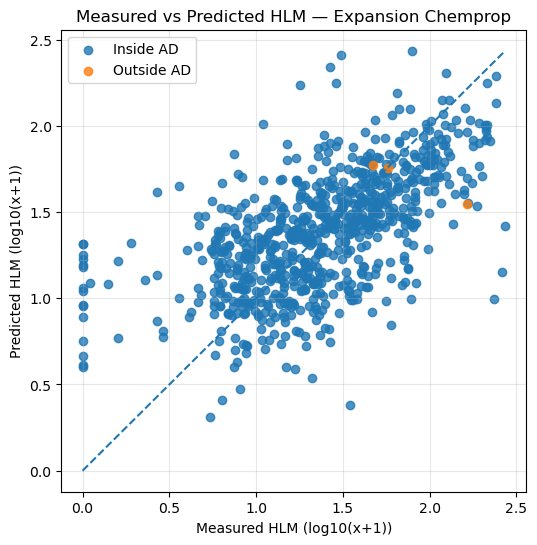

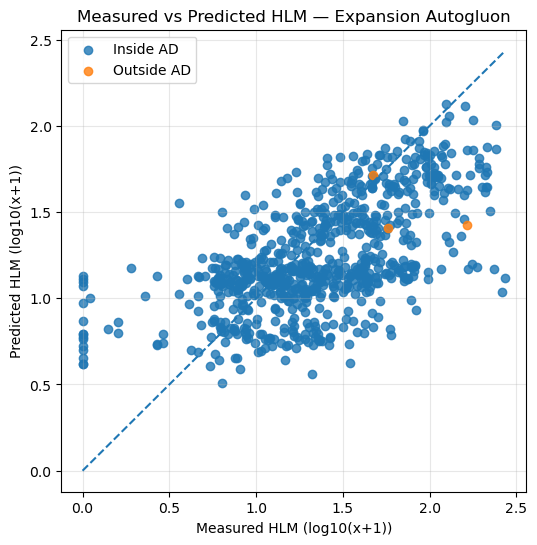

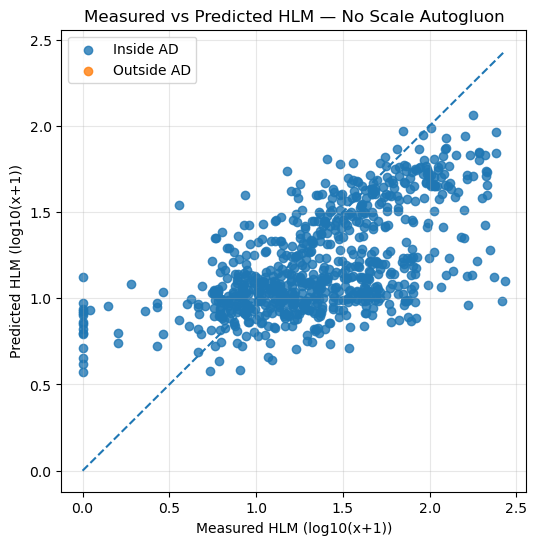

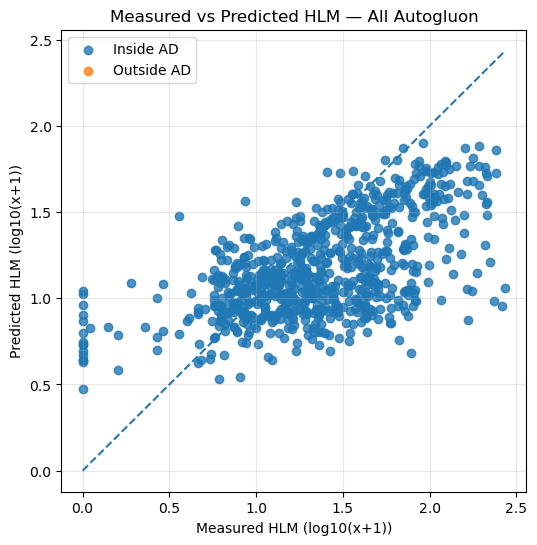

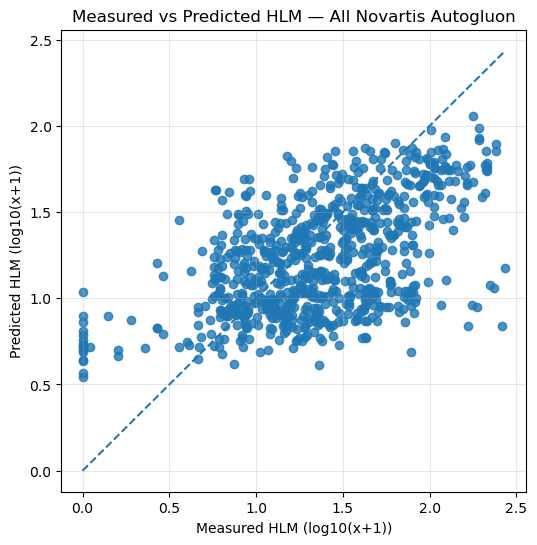

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfs_to_plot = [
    ("Expansion Chemprop", df5),
    ("Expansion Autogluon", df4),
    ("No Scale Autogluon", df3),
    ("All Autogluon", df2),
    ("All Novartis Autogluon", df1),
]

ad_col = "outside_ad_train_all_user_cutoff"

for name, dfi in dfs_to_plot:
    needed = ["hlm_value_true", "y_pred_log1p"]
    missing = [c for c in needed if c not in dfi.columns]
    if missing:
        print(f"{name}: missing required columns {missing}, skipping")
        continue

    cols = ["hlm_value_true", "y_pred_log1p"]
    has_ad = ad_col in dfi.columns
    if has_ad:
        cols.append(ad_col)

    tmp = dfi[cols].dropna().copy()

    if tmp.empty:
        print(f"{name}: no valid rows after dropping NaNs, skipping")
        continue

    y_true_plot = np.log10(np.clip(pd.to_numeric(tmp["hlm_value_true"], errors="coerce").to_numpy(), 0, None) + 1)

    y_pred_raw = np.expm1(pd.to_numeric(tmp["y_pred_log1p"], errors="coerce").to_numpy())
    y_pred_plot = np.log10(np.clip(y_pred_raw, 0, None) + 1)

    valid = np.isfinite(y_true_plot) & np.isfinite(y_pred_plot)
    y_true_plot = y_true_plot[valid]
    y_pred_plot = y_pred_plot[valid]

    plt.figure(figsize=(6, 6))

    if has_ad:
        outside_ad = (
            tmp.loc[valid, ad_col]
            .astype(str)
            .str.strip()
            .str.lower()
            .isin(["true", "1", "yes"])
            .to_numpy()
        )

        plt.scatter(
            y_true_plot[~outside_ad],
            y_pred_plot[~outside_ad],
            alpha=0.8,
            label="Inside AD"
        )

        plt.scatter(
            y_true_plot[outside_ad],
            y_pred_plot[outside_ad],
            alpha=0.8,
            label="Outside AD"
        )
        plt.legend()
    else:
        plt.scatter(y_true_plot, y_pred_plot, alpha=0.8, label="All molecules")

    mn = min(y_true_plot.min(), y_pred_plot.min())
    mx = max(y_true_plot.max(), y_pred_plot.max())
    plt.plot([mn, mx], [mn, mx], "--")

    plt.xlabel("Measured HLM (log10(x+1))")
    plt.ylabel("Predicted HLM (log10(x+1))")
    plt.title(f"Measured vs Predicted HLM — {name}")
    plt.grid(True, alpha=0.3)
    plt.show()